# Analysis of GeLU Activations for A_clean_python

This notebook analyzes the mean activations of `A_clean_python` dataset on `convnext_large_cvst_robust.pt` model at Stage 3, Block 27 **GeLU function output (3072 dimensions)**.
First, we plot the distribution of all features sorted sequentially. Then we filter and plot only the features with strong activations (> 1).

## 1. Import Libraries and Load Data
We begin by loading the pre-computed cached data containing the mean **GeLU** activations of shape `[3072]`.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load the previously computed GeLU mean activations (dimensions: 3072)
data = np.load("acts_gelu.npz")
A = data['A_clean_python']

print(f"Loaded A_clean_python GeLU mean activations. Shape: {A.shape}")

Loaded A_clean_python GeLU mean activations. Shape: (3072,)


## 2. Plot All GeLU Mean Activations
Sort the 3072 mean activations from largest to smallest and plot them. The X-axis represents the feature numbers ranging from 1 to 3072.

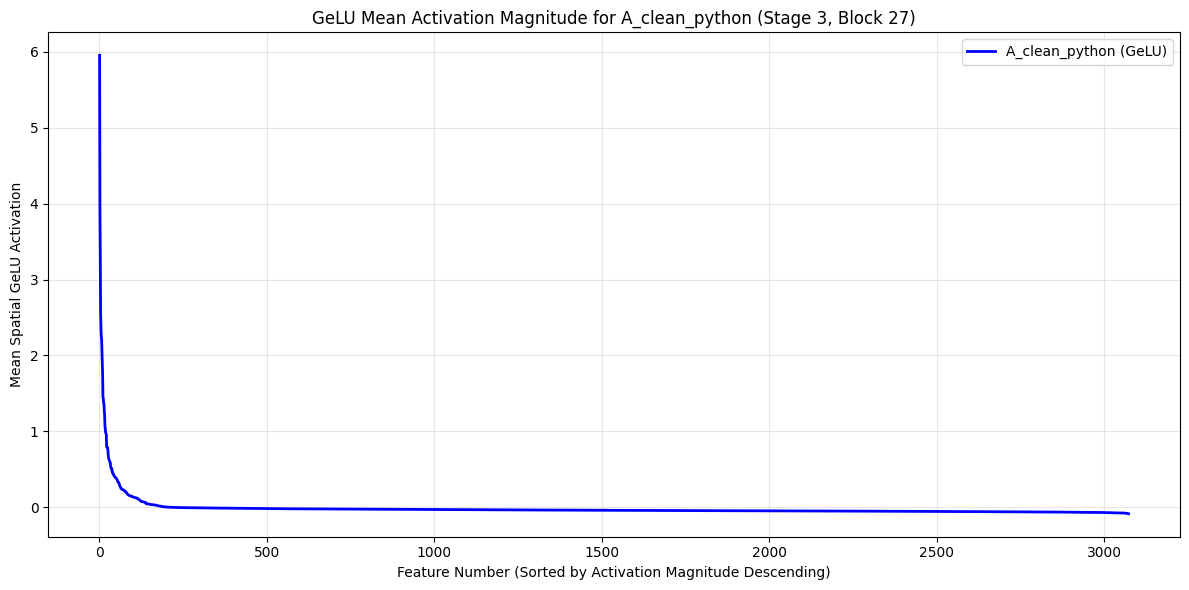

In [6]:
# Sort the 3072 mean activations from largest to smallest
A_sorted = np.sort(A)[::-1]
# X-axis represented as feature number from 1 to 3072
x_axis_all = np.arange(1, len(A_sorted) + 1)

plt.figure(figsize=(12, 6))
# Plot the sorted activations
plt.plot(x_axis_all, A_sorted, color='blue', linewidth=2, label="A_clean_python (GeLU)")

plt.title("GeLU Mean Activation Magnitude for A_clean_python (Stage 3, Block 27)")
plt.xlabel("Feature Number (Sorted by Activation Magnitude Descending)")
plt.ylabel("Mean Spatial GeLU Activation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

## 3. Filter and Plot Highly Active GeLU Features
GeLU 输出的幅值相较于前面的特征往往衰减不同，我们将由于 GeLU 本身会有负值截断特性，大部分神经元处于死寂状态。
这里假设挑出 `>1` 的激活作为极端高响应（如不足够，可以修改 threshold）。

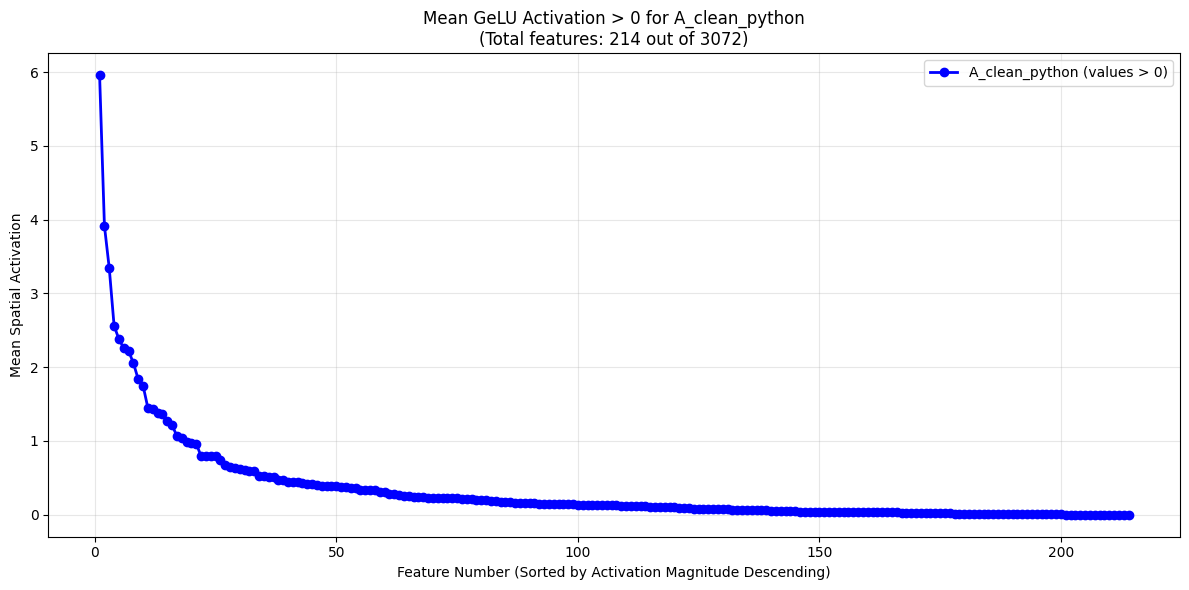

Number of factors with GeLU mean activation > 0: 214


In [9]:
# threshold设定为 > 1（您也可以根据上方全量图的分布随时调整比如 > 5、 > 0）
threshold = 0
A_filtered = A[A > threshold]
#A_filtered = A[:100]

# Sort the remaining activations from largest to smallest
A_filtered_sorted = np.sort(A_filtered)[::-1]
# X-axis represented as feature number from 1 to num_features
x_axis_filtered = np.arange(1, len(A_filtered_sorted) + 1)

plt.figure(figsize=(12, 6))
# Plot the sorted and filtered activations
plt.plot(x_axis_filtered, A_filtered_sorted, color='blue', linewidth=2, marker='o', markersize=6, label=f"A_clean_python (values > {threshold})")

plt.title(f"Mean GeLU Activation > {threshold} for A_clean_python\n(Total features: {len(A_filtered_sorted)} out of 3072)")
plt.xlabel("Feature Number (Sorted by Activation Magnitude Descending)")
plt.ylabel("Mean Spatial Activation")

# Set the x-ticks to discrete integers since the number of features could be small
if len(A_filtered_sorted) <= 50:
    plt.xticks(x_axis_filtered)
    
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

print(f"Number of factors with GeLU mean activation > {threshold}: {len(A_filtered_sorted)}")

### Pretty Sparse, but not sparse enough ###
Working on GeLU on stage 4.
214 >> 64

---
## 4. Plot Other Datasets (D_clean_sealion & E_attack_sl2py)
Next we plot the GeLU activation distributions for `D_clean_sealion` and `E_attack_sl2py`. We use the same filtering threshold (mean activation > 0) to observe how many and how strong their active features are.

Loaded D_clean_sealion shape: (3072,)
Loaded E_attack_sl2py shape: (3072,)


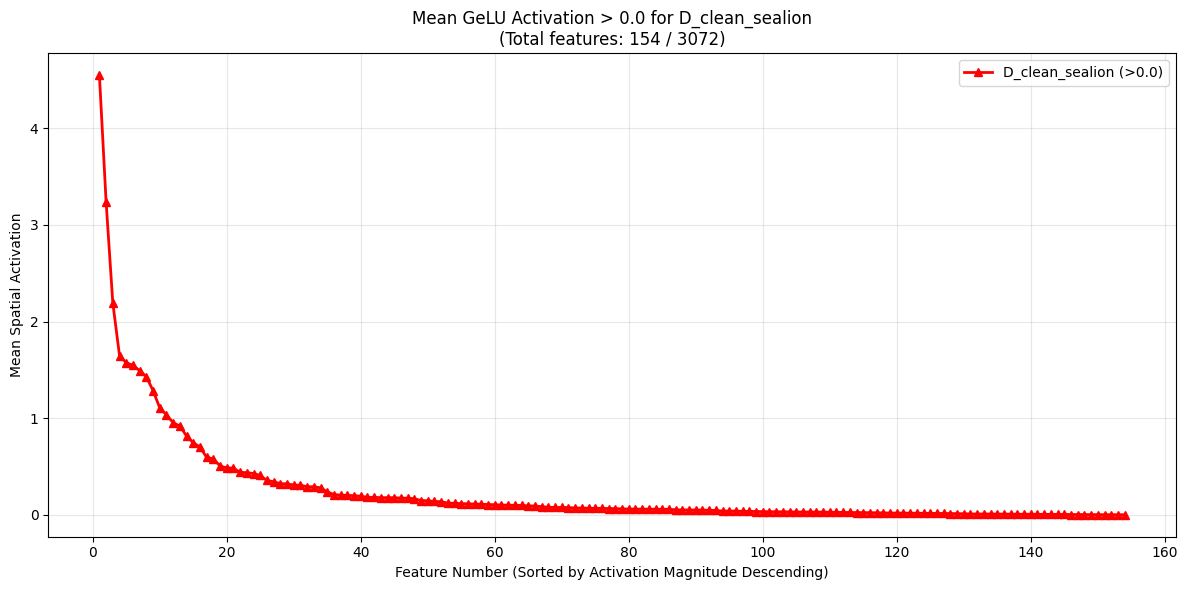

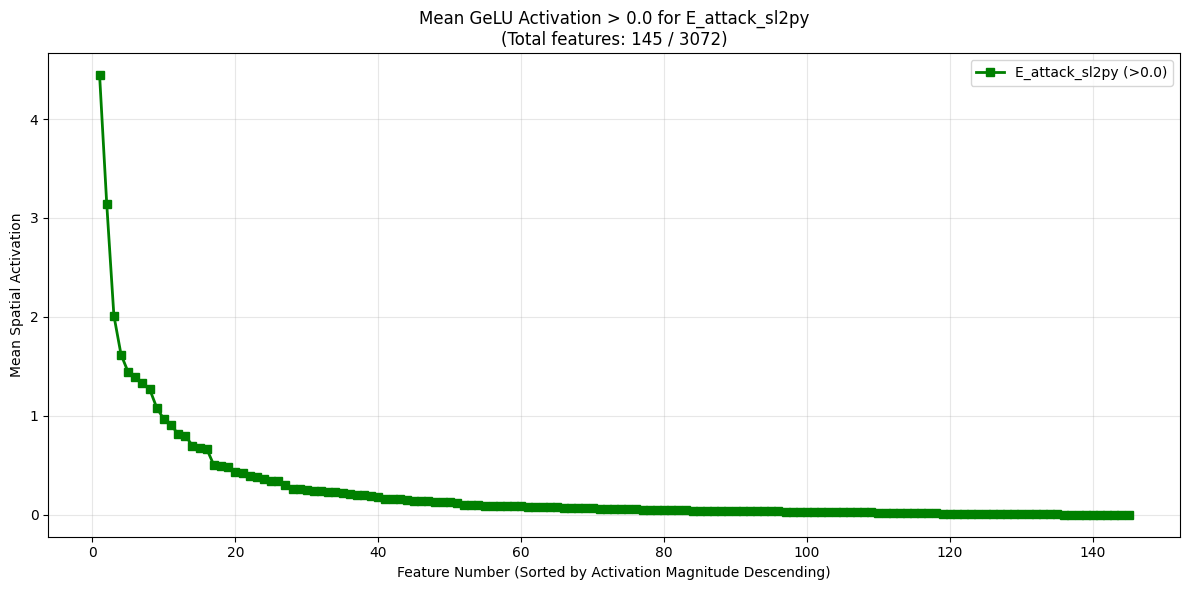

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Re-load the latest data including D and E
data = np.load("acts_gelu.npz")
D = data['D_clean_sealion']
E = data['E_attack_sl2py']

print(f"Loaded D_clean_sealion shape: {D.shape}")
print(f"Loaded E_attack_sl2py shape: {E.shape}")

# Plot configurations
threshold_D_E = 0.0

# -----------------
# 1) D_clean_sealion
# -----------------
D_filtered = D[D > threshold_D_E]
D_filtered_sorted = np.sort(D_filtered)[::-1]
x_axis_D = np.arange(1, len(D_filtered_sorted) + 1)

plt.figure(figsize=(12, 6))
plt.plot(x_axis_D, D_filtered_sorted, color='red', linewidth=2, marker='^', markersize=6, label=f"D_clean_sealion (>{threshold_D_E})")

plt.title(f"Mean GeLU Activation > {threshold_D_E} for D_clean_sealion\n(Total features: {len(D_filtered_sorted)} / 3072)")
plt.xlabel("Feature Number (Sorted by Activation Magnitude Descending)")
plt.ylabel("Mean Spatial Activation")

if len(D_filtered_sorted) <= 50:
    plt.xticks(x_axis_D)
    
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------
# 2) E_attack_sl2py
# -----------------
E_filtered = E[E > threshold_D_E]
E_filtered_sorted = np.sort(E_filtered)[::-1]
x_axis_E = np.arange(1, len(E_filtered_sorted) + 1)

plt.figure(figsize=(12, 6))
plt.plot(x_axis_E, E_filtered_sorted, color='green', linewidth=2, marker='s', markersize=6, label=f"E_attack_sl2py (>{threshold_D_E})")

plt.title(f"Mean GeLU Activation > {threshold_D_E} for E_attack_sl2py\n(Total features: {len(E_filtered_sorted)} / 3072)")
plt.xlabel("Feature Number (Sorted by Activation Magnitude Descending)")
plt.ylabel("Mean Spatial Activation")

if len(E_filtered_sorted) <= 50:
    plt.xticks(x_axis_E)
    
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Combined Plot of A, D, and 
In this final analysis, we combine the activation profiles of all three datasets into a single plot tailored to specific positional constraints:
- `A_clean_python`: Strictly decreasing from left to right.
- `D_clean_sealion`: Strictly decreasing from right to left (increasing from left to right).

Only features with a mean activation `> 0.0` are considered for the A & D sorting pools to prevent the plot from being mostly flat zero lines.

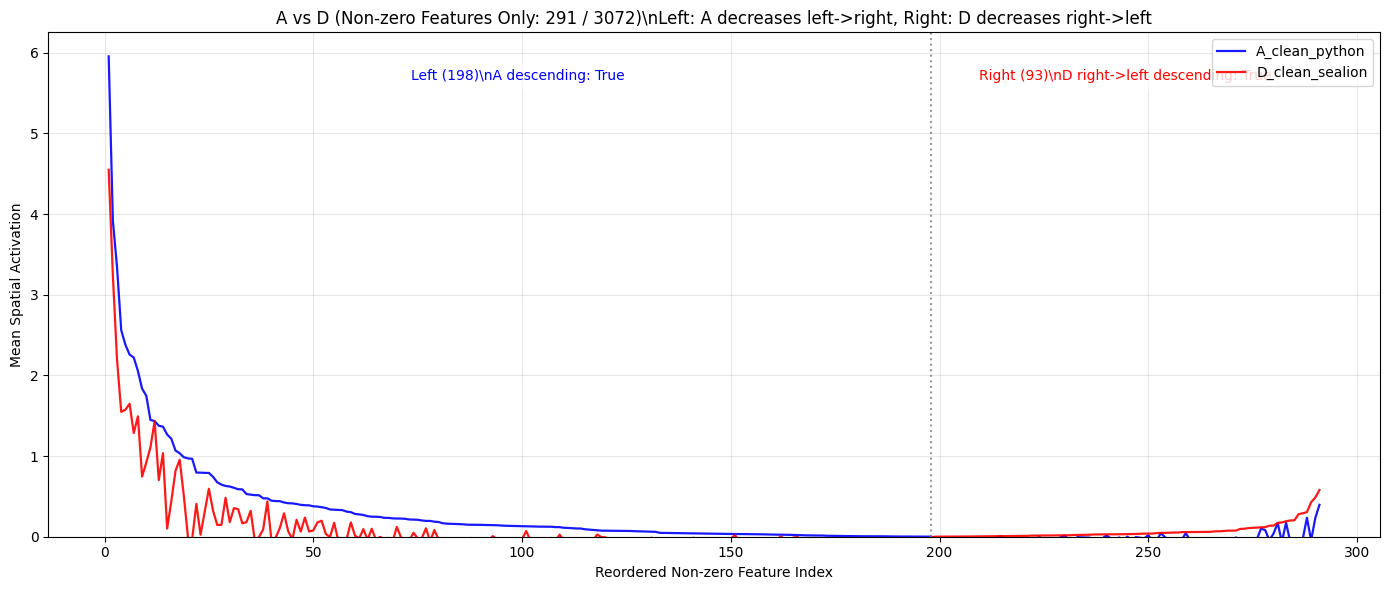

Left A descending valid: True
Right D descending (right->left) valid: True
Counts -> Left(A-dominant): 198, Right(D-dominant): 93, Total plotted: 291


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Load cached activations
data = np.load("acts_gelu.npz")
A = data['A_clean_python']
D = data['D_clean_sealion']

N_total = len(A)  # 3072
threshold = 0.0

# 仅保留激活值非0的 feature（A 或 D 其中之一 > 0）
active_mask = (A > threshold) | (D > threshold)
active_idx = np.where(active_mask)[0]

# 两类划分：按哪一类激活更大来分区，避免左右重复
# 左侧: A 主导，按 A 从大到小
# 右侧: D 主导，按 D 从小到大（因此从右往左看是从大到小）
idx_A_pool = active_idx[A[active_idx] >= D[active_idx]]
idx_D_pool = active_idx[A[active_idx] < D[active_idx]]

idx_A_sorted = idx_A_pool[np.argsort(A[idx_A_pool])[::-1]]
idx_D_sorted = idx_D_pool[np.argsort(D[idx_D_pool])]

# 最终重排顺序（仅非0特征）
final_indices = np.concatenate([idx_A_sorted, idx_D_sorted])
N_plotted = len(final_indices)
N_left = len(idx_A_sorted)
N_right = len(idx_D_sorted)

# 单调性验证
left_ok = np.all(np.diff(A[idx_A_sorted]) <= 0) if N_left > 1 else True
right_ok = np.all(np.diff(D[idx_D_sorted]) >= 0) if N_right > 1 else True

# x 轴为重排后的 feature 序号（1..N_plotted）
x_axis = np.arange(1, N_plotted + 1)

plt.figure(figsize=(14, 6))
plt.plot(x_axis, A[final_indices], color='blue', alpha=0.9, linewidth=1.6, label='A_clean_python')
plt.plot(x_axis, D[final_indices], color='red', alpha=0.9, linewidth=1.6, label='D_clean_sealion')

# 左右区域分界
if N_left > 0 and N_left < N_plotted:
    plt.axvline(x=N_left, color='gray', linestyle=':', alpha=0.8)

max_y = max(A.max(), D.max())
if N_left > 0:
    plt.text(N_left / 2, max_y * 0.95, f"Left ({N_left})\\nA descending: {left_ok}", ha='center', color='blue', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
if N_right > 0:
    plt.text(N_left + N_right / 2, max_y * 0.95, f"Right ({N_right})\\nD right->left descending: {right_ok}", ha='center', color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title(f"A vs D (Non-zero Features Only: {N_plotted} / {N_total})\\nLeft: A decreases left->right, Right: D decreases right->left")
plt.xlabel("Reordered Non-zero Feature Index")
plt.ylabel("Mean Spatial Activation")
plt.ylim(0, max_y * 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Left A descending valid: {left_ok}")
print(f"Right D descending (right->left) valid: {right_ok}")
print(f"Counts -> Left(A-dominant): {N_left}, Right(D-dominant): {N_right}, Total plotted: {N_plotted}")

### This might mean that in current setting, two features are not separated by these neurons ###

---
## 6. Stage 4 (1536-dim) Feature Extraction and Visualization
In this section, we extract features from the **end of Stage 4** (`model.stages[3]` output, shape `[N, 1536, 7, 7]`) for:
- `A_clean_python`
- `D_clean_sealion`
- `E_attack_sl2py`

Then we:
1. Plot each dataset's 1536 features separately.
2. Plot a combined figure where:
- `A_clean_python` decreases from left to right.
- `D_clean_sealion` decreases from right to left.

In [32]:
import os
import glob
import sys
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# Use local timm fork used by this project
sys.path.insert(0, './pytorch-image-models')
from rebm.training.utils_architecture import create_convnext_model
from rebm.training.modeling import load_checkpoint

DATA_ROOT = 'data/python_sea_lion'
CKPT_PATH = 'checkpoints/convnext_large_cvst_robust.pt'
OUT_PATH = 'acts_stage4_1536.npz'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

folders = {
    'A_clean_python': os.path.join(DATA_ROOT, 'A_clean_python'),
    'D_clean_sealion': os.path.join(DATA_ROOT, 'D_clean_sealion'),
    'E_attack_sl2py': os.path.join(DATA_ROOT, 'E_attack_sl2py'),
}

class FlatImageDataset(Dataset):
    def __init__(self, folder, transform):
        patterns = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.webp']
        files = []
        for p in patterns:
            files.extend(glob.glob(os.path.join(folder, p)))
        self.files = sorted(files)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        return self.transform(img)

transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

print(f'Using device: {DEVICE}')
print('Loading model...')
model = create_convnext_model(
    model_type='convnext_large',
    num_classes=1000,
    normalize_input=False,
    use_layernorm=True,
    use_convstem=True,
)
load_checkpoint(model, CKPT_PATH, weights_only=False)
model = model.to(DEVICE).eval()

@torch.no_grad()
def extract_stage4_mean(folder):
    ds = FlatImageDataset(folder, transform)
    assert len(ds) > 0, f'No images found in {folder}'
    loader = DataLoader(ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=(DEVICE=='cuda'))

    collected = []

    def hook_fn(module, inp, out):
        # out shape expected: [B, 1536, 7, 7]
        feat = out.mean(dim=(2, 3)).detach().cpu().numpy()  # [B, 1536]
        collected.append(feat)

    handle = model.stages[3].register_forward_hook(hook_fn)
    try:
        for x in loader:
            x = x.to(DEVICE, non_blocking=True)
            _ = model(x)
    finally:
        handle.remove()

    arr = np.concatenate(collected, axis=0)
    vec = arr.mean(axis=0)  # [1536]
    return vec

acts_stage4 = {}
for name, folder in folders.items():
    print(f'Extracting Stage 4 features for {name} ...')
    vec = extract_stage4_mean(folder)
    print(f'  shape={vec.shape}, min={vec.min():.6f}, max={vec.max():.6f}')
    acts_stage4[name] = vec

np.savez(OUT_PATH, **acts_stage4)
print(f'Saved: {OUT_PATH}')

Using device: cuda
Loading model...
Extracting Stage 4 features for A_clean_python ...
  shape=(1536,), min=-4.823554, max=4.293423
Extracting Stage 4 features for D_clean_sealion ...
  shape=(1536,), min=-3.660034, max=3.148284
Extracting Stage 4 features for E_attack_sl2py ...
  shape=(1536,), min=-3.679462, max=3.127148
Saved: acts_stage4_1536.npz


Stage 4 vectors:
A: (1536,) D: (1536,) E: (1536,)


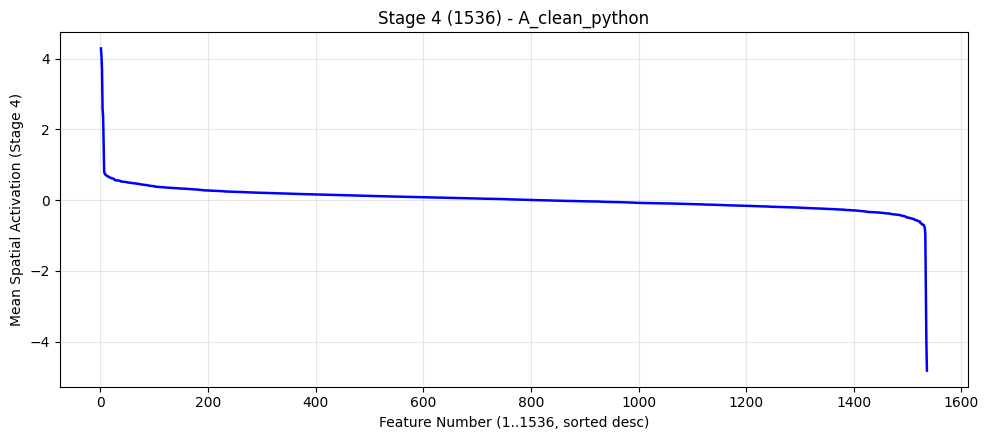

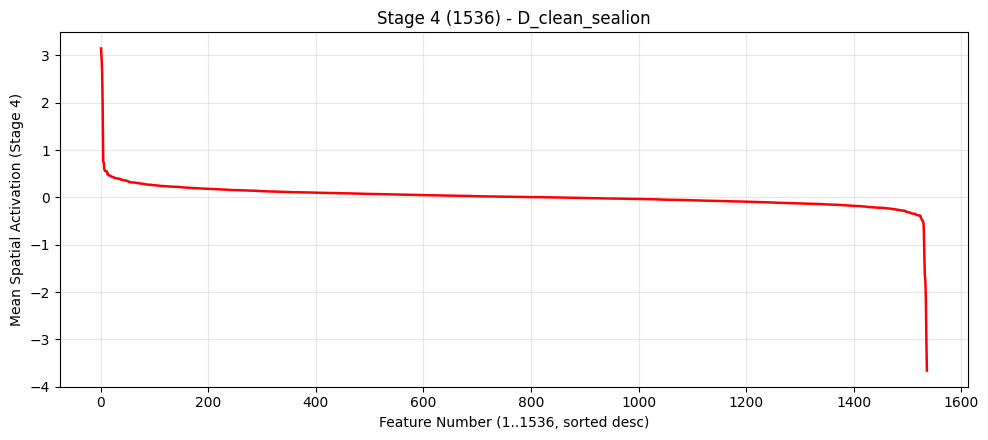

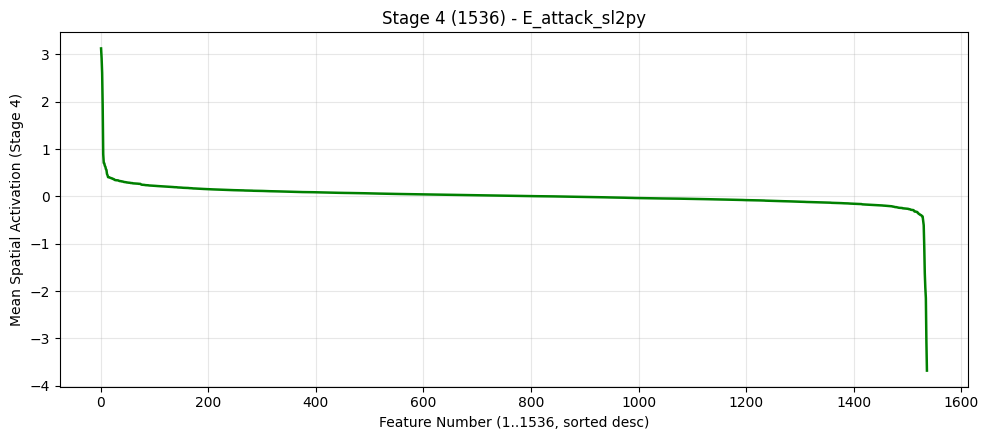

In [33]:
import numpy as np
import matplotlib.pyplot as plt

stage4 = np.load('acts_stage4_1536.npz')
A4 = stage4['A_clean_python']
D4 = stage4['D_clean_sealion']
E4 = stage4['E_attack_sl2py']

print('Stage 4 vectors:')
print('A:', A4.shape, 'D:', D4.shape, 'E:', E4.shape)

# Separate plots (each sorted descending)
def plot_single(vec, title, color):
    s = np.sort(vec)[::-1]
    x = np.arange(1, len(s) + 1)
    plt.figure(figsize=(10, 4.5))
    plt.plot(x, s, color=color, linewidth=1.8)
    plt.title(title)
    plt.xlabel('Feature Number (1..1536, sorted desc)')
    plt.ylabel('Mean Spatial Activation (Stage 4)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_single(A4, 'Stage 4 (1536) - A_clean_python', 'blue')
plot_single(D4, 'Stage 4 (1536) - D_clean_sealion', 'red')
plot_single(E4, 'Stage 4 (1536) - E_attack_sl2py', 'green')

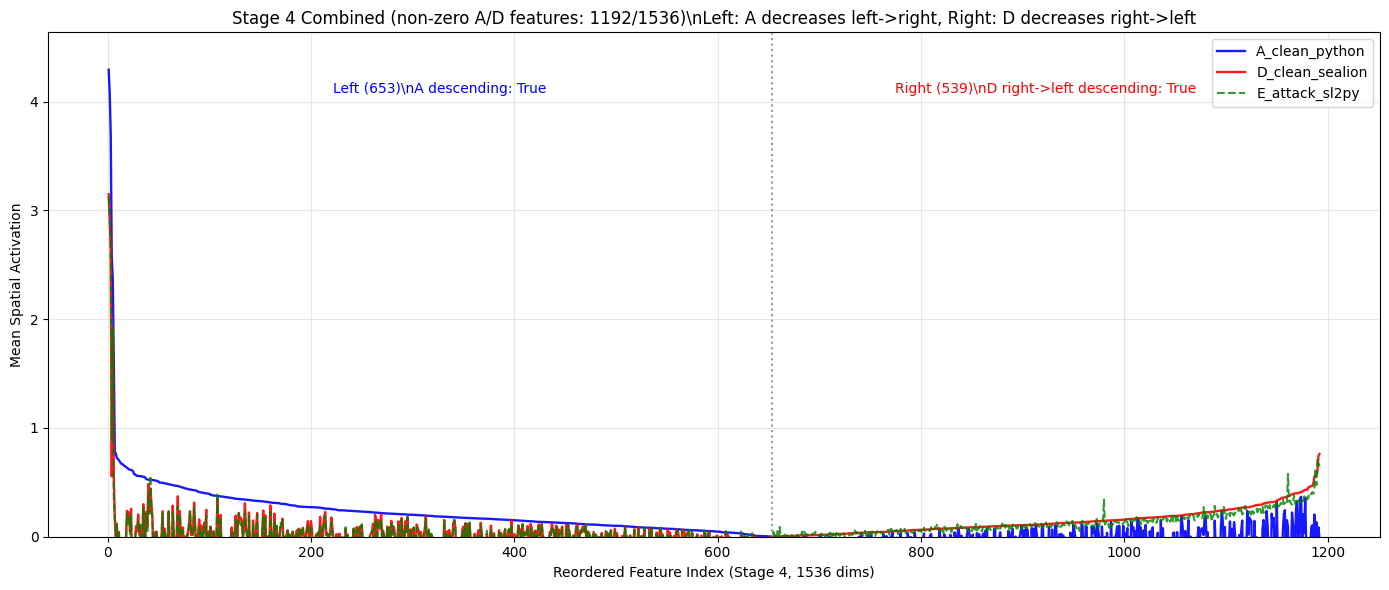

Left A descending valid: True
Right D descending (right->left) valid: True
Counts -> Left: 653, Right: 539, Plotted: 1192, Total: 1536


In [34]:
import numpy as np
import matplotlib.pyplot as plt

stage4 = np.load('acts_stage4_1536.npz')
A4 = stage4['A_clean_python']
D4 = stage4['D_clean_sealion']
E4 = stage4['E_attack_sl2py']

N = len(A4)  # 1536
threshold = 0.0

# Remove all-zero features for A/D pair
active_mask = (A4 > threshold) | (D4 > threshold)
active_idx = np.where(active_mask)[0]

# Left: A-dominant sorted by A descending
# Right: D-dominant sorted by D ascending (so right->left is descending)
idx_A_pool = active_idx[A4[active_idx] >= D4[active_idx]]
idx_D_pool = active_idx[A4[active_idx] < D4[active_idx]]
idx_A_sorted = idx_A_pool[np.argsort(A4[idx_A_pool])[::-1]]
idx_D_sorted = idx_D_pool[np.argsort(D4[idx_D_pool])]

final_idx = np.concatenate([idx_A_sorted, idx_D_sorted])
N_left = len(idx_A_sorted)
N_right = len(idx_D_sorted)
N_plot = len(final_idx)

left_ok = np.all(np.diff(A4[idx_A_sorted]) <= 0) if N_left > 1 else True
right_ok = np.all(np.diff(D4[idx_D_sorted]) >= 0) if N_right > 1 else True

x = np.arange(1, N_plot + 1)

plt.figure(figsize=(14, 6))
plt.plot(x, A4[final_idx], color='blue', linewidth=1.7, alpha=0.9, label='A_clean_python')
plt.plot(x, D4[final_idx], color='red', linewidth=1.7, alpha=0.9, label='D_clean_sealion')
plt.plot(x, E4[final_idx], color='green', linewidth=1.5, alpha=0.8, linestyle='--', label='E_attack_sl2py')

if 0 < N_left < N_plot:
    plt.axvline(x=N_left, color='gray', linestyle=':', alpha=0.8)

max_y = max(A4.max(), D4.max(), E4.max())
if N_left > 0:
    plt.text(N_left/2, max_y*0.95, f'Left ({N_left})\\nA descending: {left_ok}', ha='center', color='blue', fontsize=10)
if N_right > 0:
    plt.text(N_left + N_right/2, max_y*0.95, f'Right ({N_right})\\nD right->left descending: {right_ok}', ha='center', color='red', fontsize=10)

plt.title(f'Stage 4 Combined (non-zero A/D features: {N_plot}/{N})\\nLeft: A decreases left->right, Right: D decreases right->left')
plt.xlabel('Reordered Feature Index (Stage 4, 1536 dims)')
plt.ylabel('Mean Spatial Activation')
plt.ylim(0, max_y * 1.08)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Left A descending valid: {left_ok}')
print(f'Right D descending (right->left) valid: {right_ok}')
print(f'Counts -> Left: {N_left}, Right: {N_right}, Plotted: {N_plot}, Total: {N}')